# Singular Spectrum Analysis (SSA) for Speech Signals

This notebook demonstrates how to apply Singular Spectrum Analysis to decompose and reconstruct speech signals.

SSA is a powerful technique for:
- Signal decomposition
- Noise reduction
- Trend extraction
- Periodic component identification

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from scipy.linalg import svd
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    # Fallback to a built-in style if seaborn style is not available
    plt.style.use('ggplot')
    
%matplotlib inline

## 1. Load Speech Signal

Load a speech audio file or generate a synthetic signal.

In [78]:
# Load your audio file - update this path to point to your audio file
audio_path = '../data/overlap_100pct_02apt_50/0_overlap/672-122797-0026_OV0.flac'

# Check if file exists, if not provide helpful message
import os
if not os.path.exists(audio_path):
    print(f"File not found: {audio_path}")
    print("\nPlease update the 'audio_path' variable to point to your audio file.")
    print("Example paths:")
    print("  - '../data/overlap_50pct/0_overlap/your_file.flac'")
    print("  - 'path/to/your/audio.wav'")
    raise FileNotFoundError(f"Audio file not found: {audio_path}")

signal_noisy, sr = librosa.load(audio_path, sr=None)  # sr=None preserves original sample rate

# Get actual duration from the loaded file
duration = len(signal_noisy) / sr

# Normalize
signal_noisy = signal_noisy / np.max(np.abs(signal_noisy))

# For reference comparisons, use the loaded signal as both signal and signal_noisy
signal = signal_noisy.copy()

print(f"Loaded: {os.path.basename(audio_path)}")
print(f"Signal length: {len(signal_noisy)} samples ({duration:.2f} seconds)")
print(f"Sample rate: {sr} Hz")

Loaded: 672-122797-0026_OV0.flac
Signal length: 222400 samples (13.90 seconds)
Sample rate: 16000 Hz


## 2. Visualize Original Signal

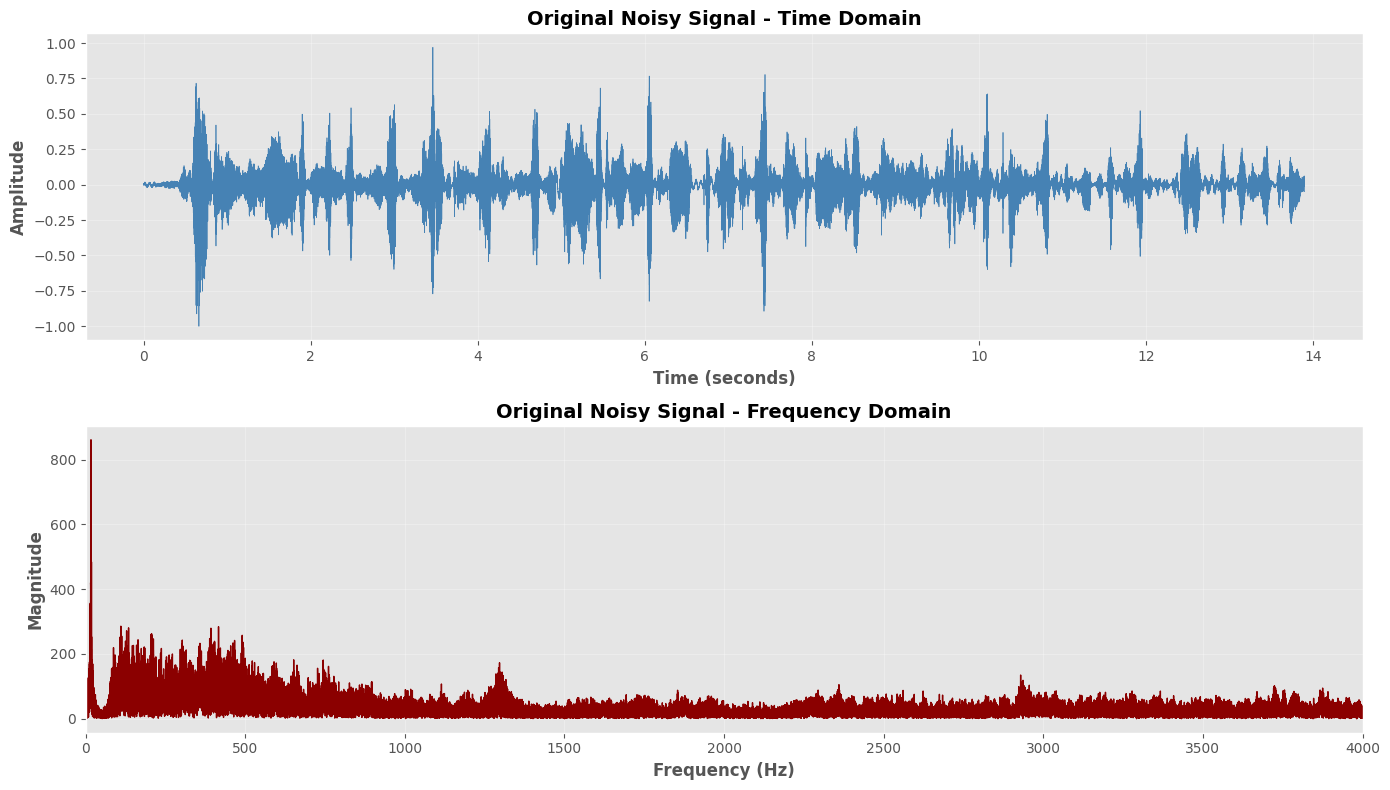


🔊 Original Noisy Signal:


In [79]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time domain
time = np.arange(len(signal_noisy)) / sr
axes[0].plot(time, signal_noisy, linewidth=0.5, color='steelblue')
axes[0].set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude', fontsize=12, fontweight='bold')
axes[0].set_title('Original Noisy Signal - Time Domain', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Frequency domain
fft = np.fft.fft(signal_noisy)
freqs = np.fft.fftfreq(len(signal_noisy), 1/sr)
positive_freqs = freqs[:len(freqs)//2]
magnitude = np.abs(fft[:len(fft)//2])

axes[1].plot(positive_freqs, magnitude, linewidth=1, color='darkred')
axes[1].set_xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Magnitude', fontsize=12, fontweight='bold')
axes[1].set_title('Original Noisy Signal - Frequency Domain', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 4000])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Play original audio
print("\n🔊 Original Noisy Signal:")
display(Audio(signal_noisy, rate=sr))

## 3. Singular Spectrum Analysis (SSA)

SSA decomposes a time series into components using SVD on the trajectory matrix.

In [80]:
def segment_into_frames(signal, frame_size):
    """
    Segment signal into non-overlapping frames.
    
    Args:
        signal: Input time series
        frame_size: Size of each frame
    
    Returns:
        frames: List of frames (2D array: num_frames x frame_size)
        num_frames: Number of frames created
    """
    num_frames = len(signal) // frame_size
    # Trim signal to fit exact number of frames
    signal_trimmed = signal[:num_frames * frame_size]
    
    # Reshape into frames
    frames = signal_trimmed.reshape(num_frames, frame_size)
    
    return frames, num_frames


def create_trajectory_matrix(signal, window_length):
    """
    Create trajectory matrix (Hankel matrix) from signal.
    
    Args:
        signal: Input time series
        window_length: Window length L (embedding dimension)
    
    Returns:
        Trajectory matrix of shape (L, K) where K = N - L + 1
    """
    N = len(signal)
    K = N - window_length + 1
    
    # Create trajectory matrix
    X = np.zeros((window_length, K))
    for i in range(K):
        X[:, i] = signal[i:i + window_length]
    
    return X


def perform_ssa(signal, window_length):
    """
    Perform Singular Spectrum Analysis.
    
    Args:
        signal: Input time series
        window_length: Window length L
    
    Returns:
        U: Left singular vectors
        s: Singular values
        Vt: Right singular vectors (transposed)
    """
    # Step 1: Embedding - create trajectory matrix
    X = create_trajectory_matrix(signal, window_length)
    
    # Step 2: SVD decomposition
    U, s, Vt = svd(X, full_matrices=False)
    
    return U, s, Vt, X


def reconstruct_component(U, s, Vt, component_indices, signal_length):
    """
    Reconstruct signal from selected SSA components.
    
    Args:
        U: Left singular vectors
        s: Singular values
        Vt: Right singular vectors
        component_indices: List of component indices to use
        signal_length: Original signal length
    
    Returns:
        Reconstructed signal
    """
    window_length = U.shape[0]
    K = Vt.shape[1]
    
    # Reconstruct trajectory matrix for selected components
    X_reconstructed = np.zeros((window_length, K))
    for i in component_indices:
        X_reconstructed += s[i] * np.outer(U[:, i], Vt[i, :])
    
    # Diagonal averaging (Hankelization) to get back the signal
    signal_reconstructed = np.zeros(signal_length)
    
    for k in range(signal_length):
        # Average over anti-diagonal
        count = 0
        total = 0
        
        for i in range(window_length):
            j = k - i
            if 0 <= j < K:
                total += X_reconstructed[i, j]
                count += 1
        
        signal_reconstructed[k] = total / count if count > 0 else 0
    
    return signal_reconstructed


# Segment signal into non-overlapping frames
frame_size = 200
frames, num_frames = segment_into_frames(signal_noisy, frame_size)
print(f"Frame size: {frame_size} samples")
print(f"Number of frames: {num_frames}")
print(f"Total samples used: {num_frames * frame_size} (out of {len(signal_noisy)})")

# Set window length for SSA (typically N/4 to N/2 of frame size)
window_length = frame_size // 2
print(f"\nSSA window length: {window_length}")

# Perform SSA on the first frame as example
print(f"\nPerforming Singular Spectrum Analysis on frame 1...")
U, s, Vt, X = perform_ssa(frames[0], window_length)
print(f"Trajectory matrix shape: {X.shape}")
print(f"Number of singular values: {len(s)}")

Frame size: 200 samples
Number of frames: 1112
Total samples used: 222400 (out of 222400)

SSA window length: 100

Performing Singular Spectrum Analysis on frame 1...
Trajectory matrix shape: (100, 101)
Number of singular values: 100


### 3.1 Visualize Frame Segmentation

Show how the signal is divided into non-overlapping frames.

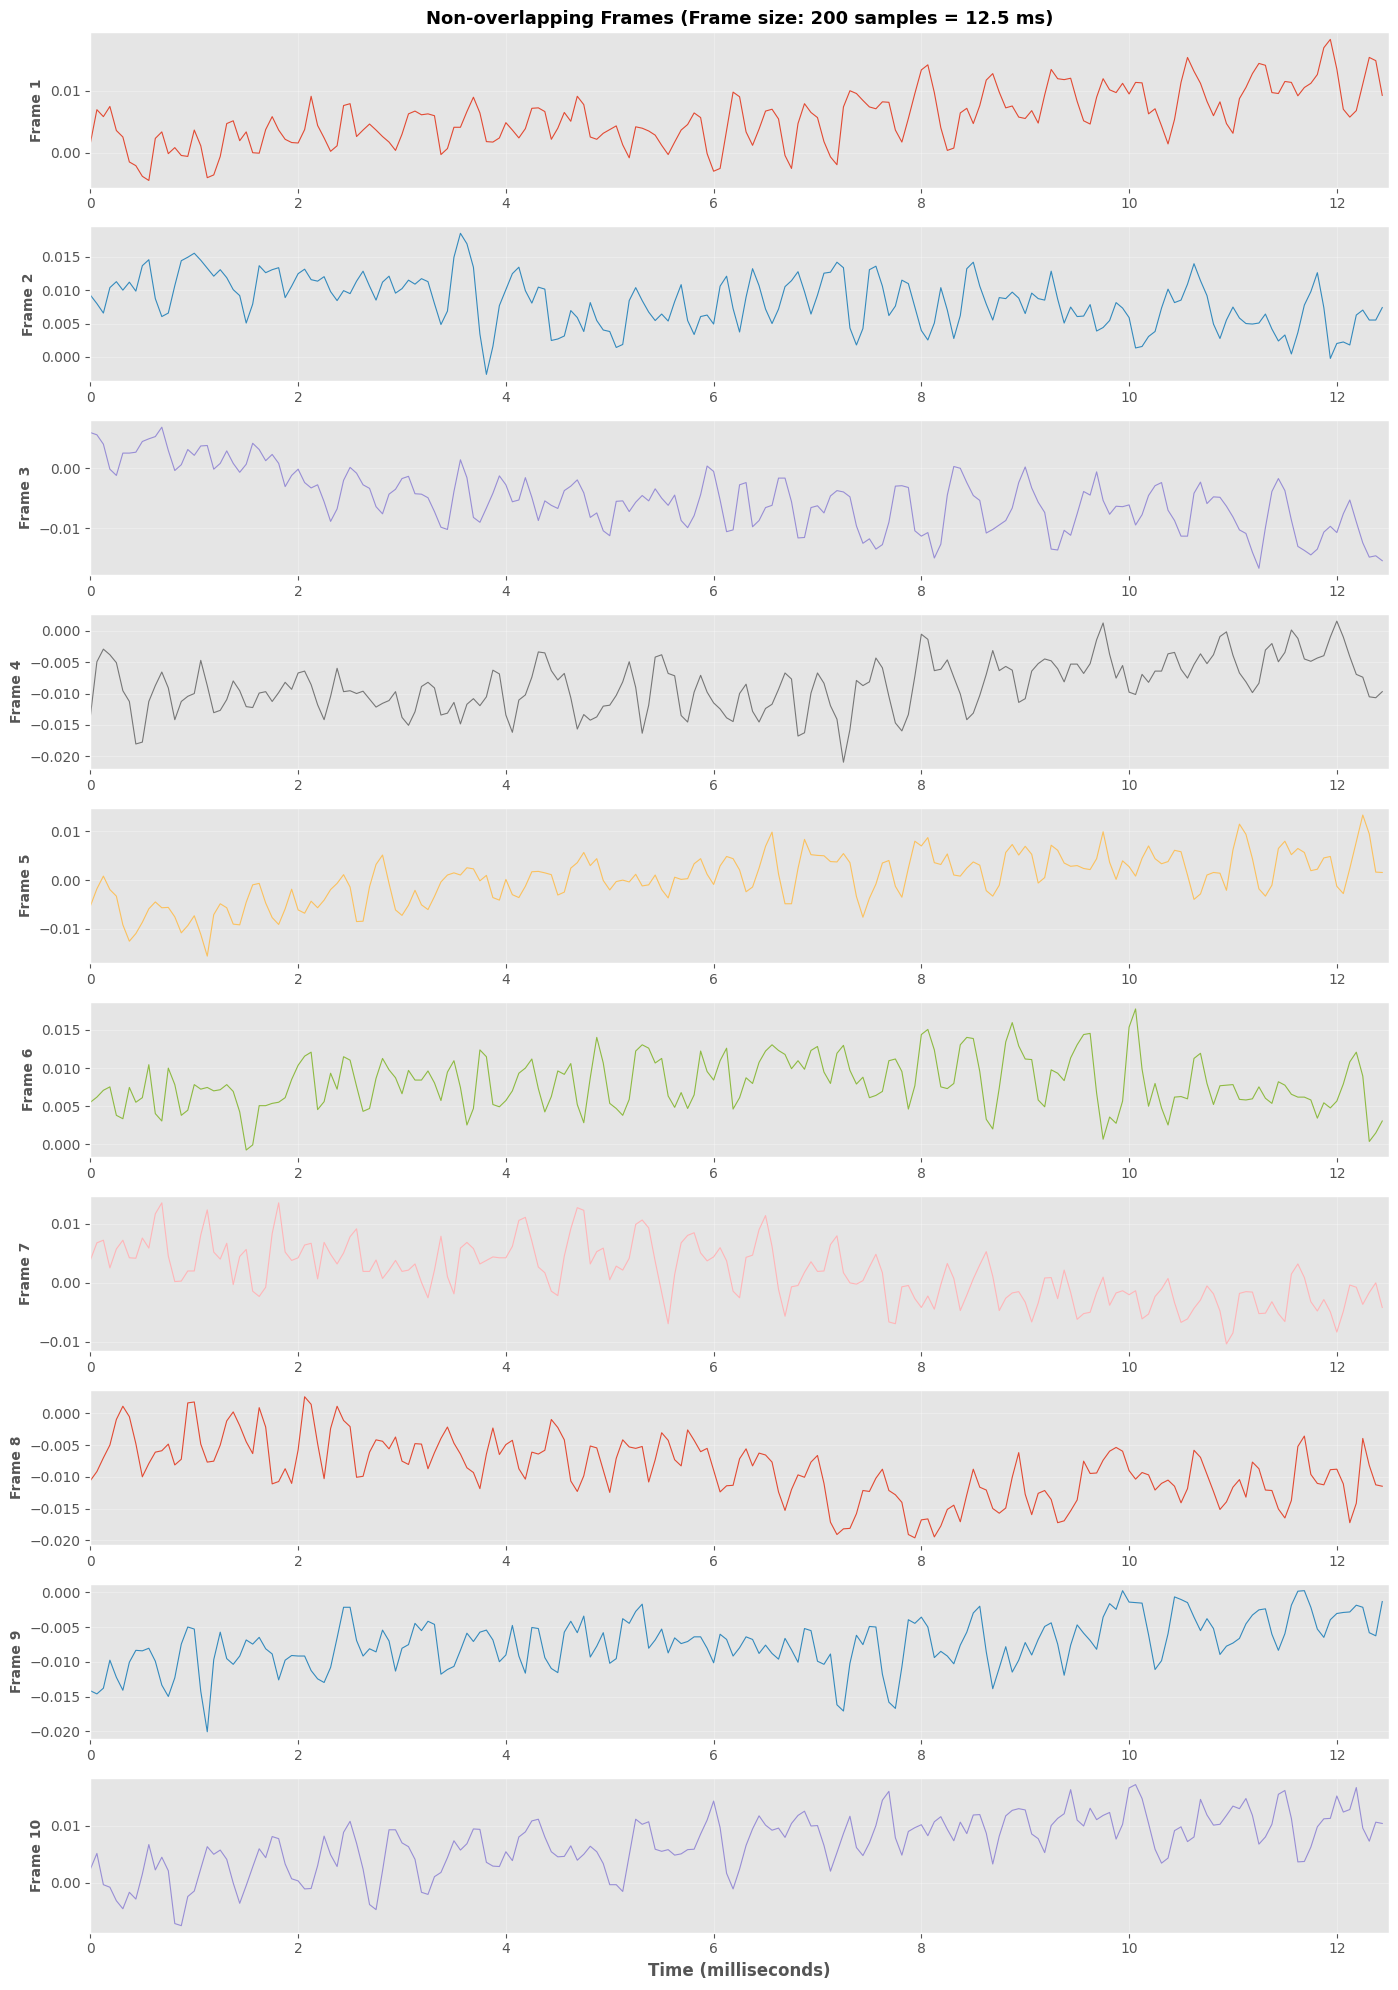


Showing first 10 frames out of 1112 total frames
Each frame: 200 samples = 12.50 ms


In [81]:
# Visualize first 10 frames
num_frames_to_plot = min(10, num_frames)
fig, axes = plt.subplots(num_frames_to_plot, 1, figsize=(14, 2 * num_frames_to_plot))

if num_frames_to_plot == 1:
    axes = [axes]

for i in range(num_frames_to_plot):
    time_frame = np.arange(frame_size) / sr * 1000  # Convert to milliseconds
    axes[i].plot(time_frame, frames[i], linewidth=0.8, color=f'C{i}')
    axes[i].set_ylabel(f'Frame {i+1}', fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, frame_size / sr * 1000])
    
    if i == 0:
        axes[i].set_title(f'Non-overlapping Frames (Frame size: {frame_size} samples = {frame_size/sr*1000:.1f} ms)', 
                         fontsize=13, fontweight='bold')

axes[-1].set_xlabel('Time (milliseconds)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nShowing first {num_frames_to_plot} frames out of {num_frames} total frames")
print(f"Each frame: {frame_size} samples = {frame_size/sr*1000:.2f} ms")

## 4. Analyze Singular Values

Examine the contribution of each component.

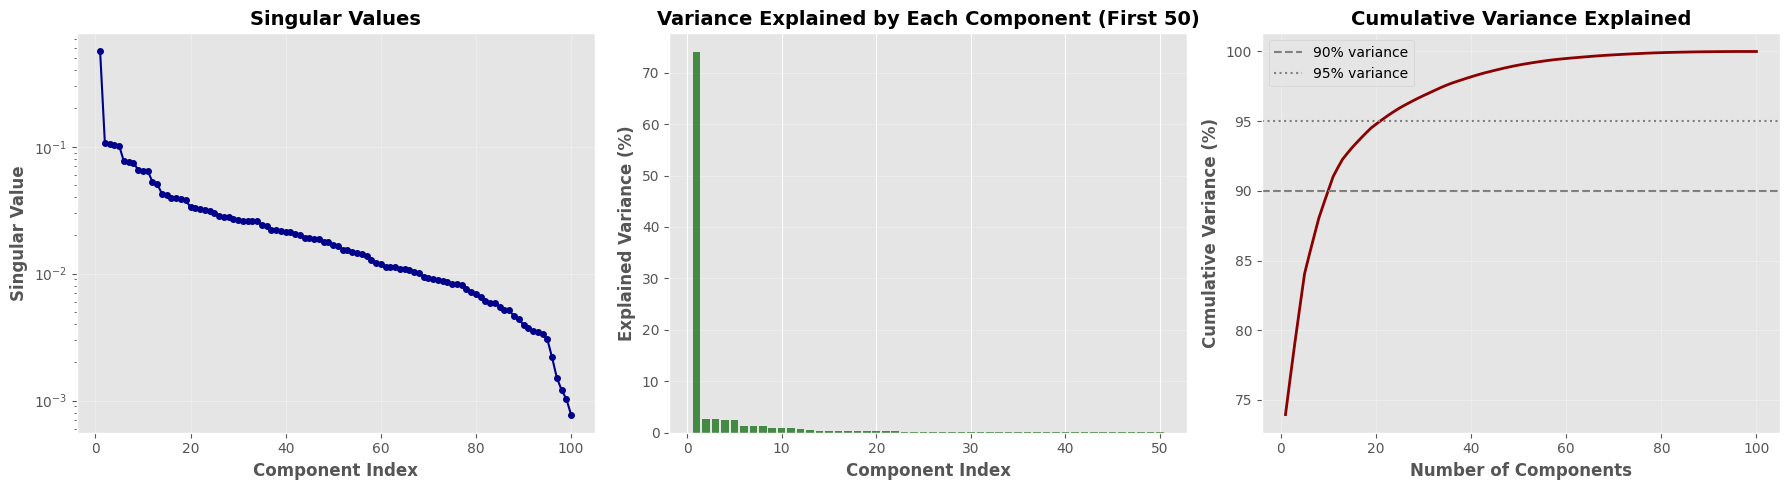


Top 10 components explain 90.04% of variance
Components needed for 90% variance: 10
Components needed for 95% variance: 21


In [82]:
# Calculate contribution of each component
explained_variance = (s ** 2) / np.sum(s ** 2) * 100
cumulative_variance = np.cumsum(explained_variance)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Singular values
axes[0].plot(range(1, len(s) + 1), s, 'o-', color='darkblue', markersize=4)
axes[0].set_xlabel('Component Index', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Singular Value', fontsize=12, fontweight='bold')
axes[0].set_title('Singular Values', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Explained variance
axes[1].bar(range(1, min(51, len(s) + 1)), explained_variance[:50], color='darkgreen', alpha=0.7)
axes[1].set_xlabel('Component Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Explained Variance (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Variance Explained by Each Component (First 50)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Cumulative variance
axes[2].plot(range(1, len(s) + 1), cumulative_variance, color='darkred', linewidth=2)
axes[2].axhline(y=90, color='gray', linestyle='--', label='90% variance')
axes[2].axhline(y=95, color='gray', linestyle=':', label='95% variance')
axes[2].set_xlabel('Number of Components', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Cumulative Variance (%)', fontsize=12, fontweight='bold')
axes[2].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for 90% and 95% variance
n_components_90 = np.argmax(cumulative_variance >= 90) + 1
n_components_95 = np.argmax(cumulative_variance >= 95) + 1

print(f"\nTop 10 components explain {cumulative_variance[9]:.2f}% of variance")
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")

## 5. Reconstruct Signal with Different Component Sets

Experiment with different numbers of components to see their effect.

In [83]:
# Define different reconstruction scenarios
reconstructions = {
    'Top 3 components': list(range(3)),
    'Top 5 components': list(range(5)),
    'Top 10 components': list(range(10)),
    'Top 15 components': list(range(15)),
}

# Reconstruct each frame with different component sets
reconstructed_frames = {}
for name, indices in reconstructions.items():
    frame_reconstructions = []
    for frame_idx in range(num_frames):
        # Perform SSA on this frame
        U_frame, s_frame, Vt_frame, X_frame = perform_ssa(frames[frame_idx], window_length)
        # Reconstruct with selected components
        rec_frame = reconstruct_component(U_frame, s_frame, Vt_frame, indices, frame_size)
        frame_reconstructions.append(rec_frame)
    
    # Concatenate all frames back into full signal
    reconstructed_frames[name] = np.concatenate(frame_reconstructions)
    print(f"Reconstructed with {name} per frame")

# Store full reconstructed signals
reconstructed_signals = reconstructed_frames

Reconstructed with Top 3 components per frame
Reconstructed with Top 5 components per frame
Reconstructed with Top 5 components per frame
Reconstructed with Top 10 components per frame
Reconstructed with Top 10 components per frame
Reconstructed with Top 15 components per frame
Reconstructed with Top 15 components per frame


## 6. Visualize Reconstructed Signals

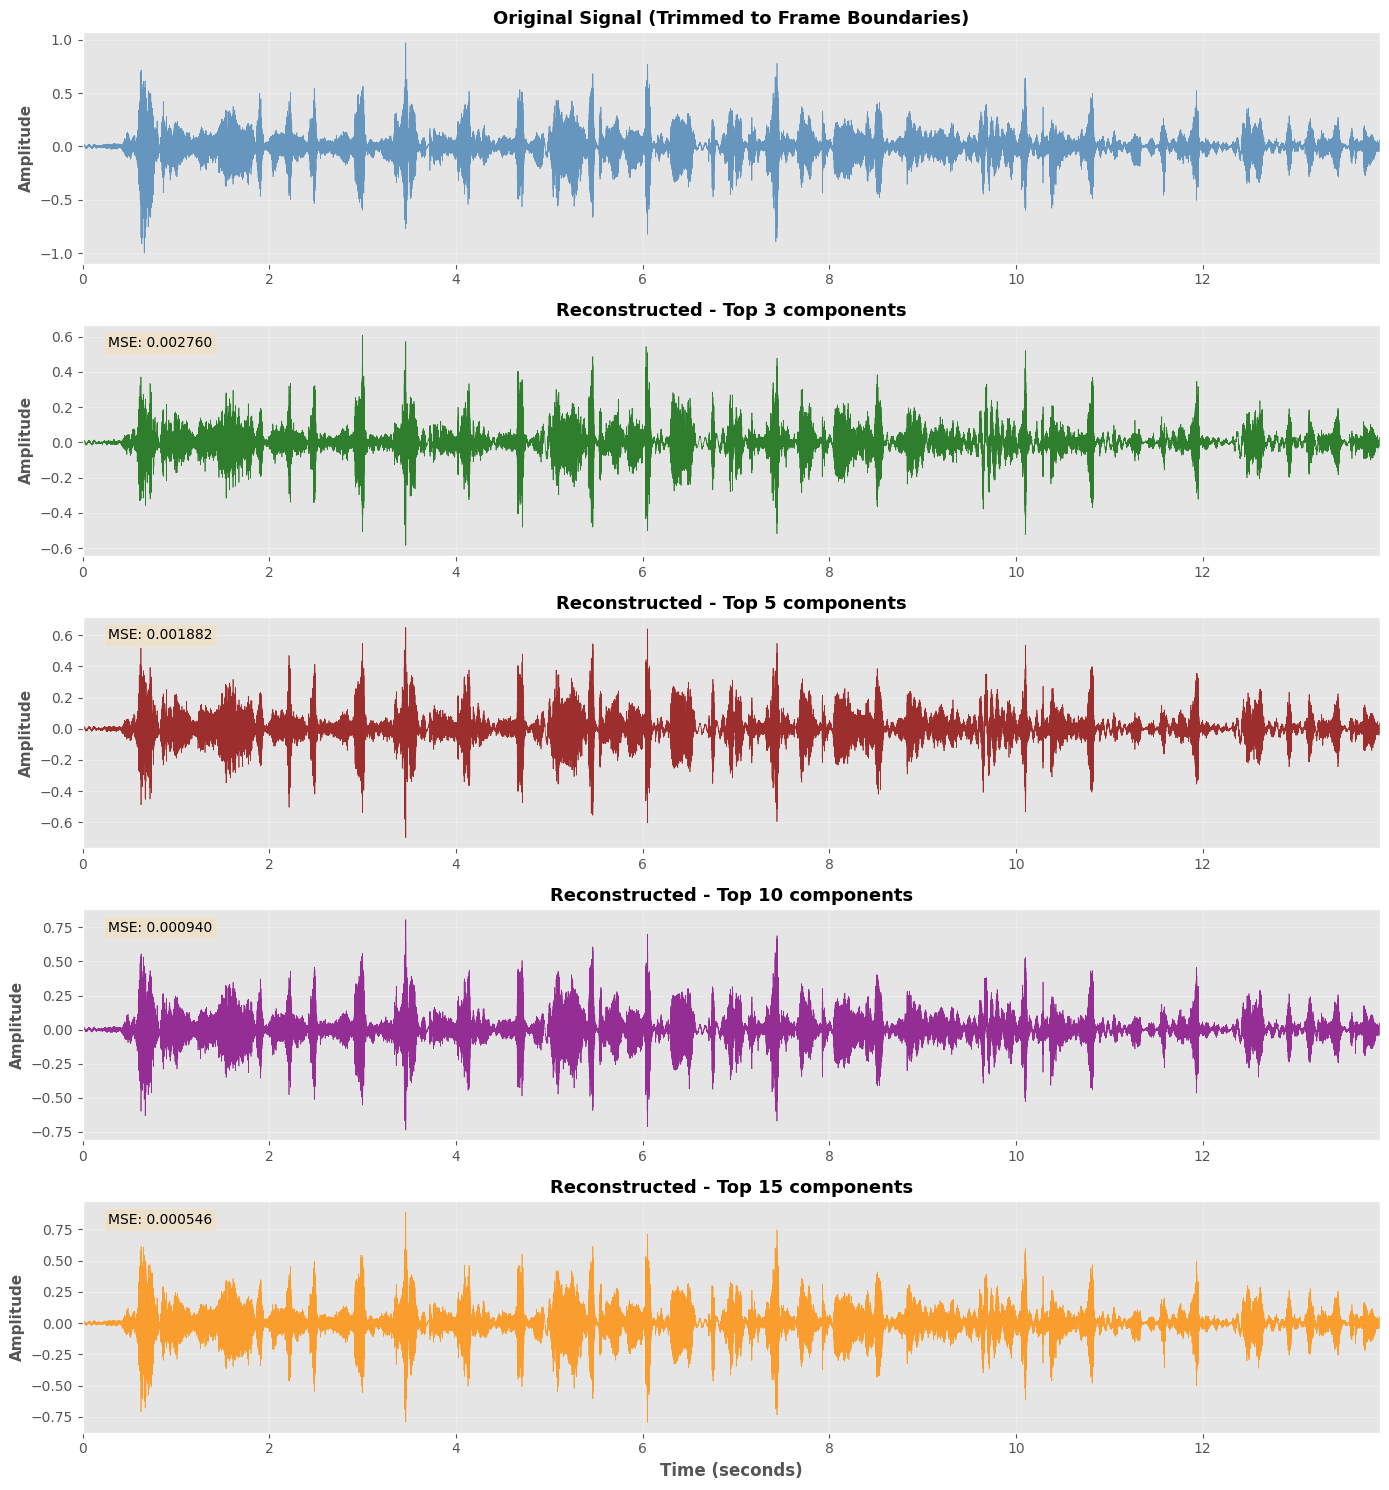

In [84]:
fig, axes = plt.subplots(len(reconstructions) + 1, 1, figsize=(14, 3 * (len(reconstructions) + 1)))

# Use trimmed signal length for comparison
signal_trimmed = signal_noisy[:num_frames * frame_size]
time = np.arange(len(signal_trimmed)) / sr

# Original signal (trimmed)
axes[0].plot(time, signal_trimmed, linewidth=0.5, color='steelblue', alpha=0.8)
axes[0].set_ylabel('Amplitude', fontsize=11, fontweight='bold')
axes[0].set_title('Original Signal (Trimmed to Frame Boundaries)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, len(signal_trimmed) / sr])

# Reconstructed signals
colors = ['darkgreen', 'darkred', 'purple', 'darkorange']
for idx, (name, signal_rec) in enumerate(reconstructed_signals.items(), 1):
    axes[idx].plot(time, signal_rec, linewidth=0.5, color=colors[idx-1], alpha=0.8)
    axes[idx].set_ylabel('Amplitude', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Reconstructed - {name}', fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, len(signal_rec) / sr])
    
    # Calculate MSE
    mse = np.mean((signal_rec - signal_trimmed)**2)
    axes[idx].text(0.02, 0.95, f'MSE: {mse:.6f}', 
                   transform=axes[idx].transAxes, fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Compare Spectrograms

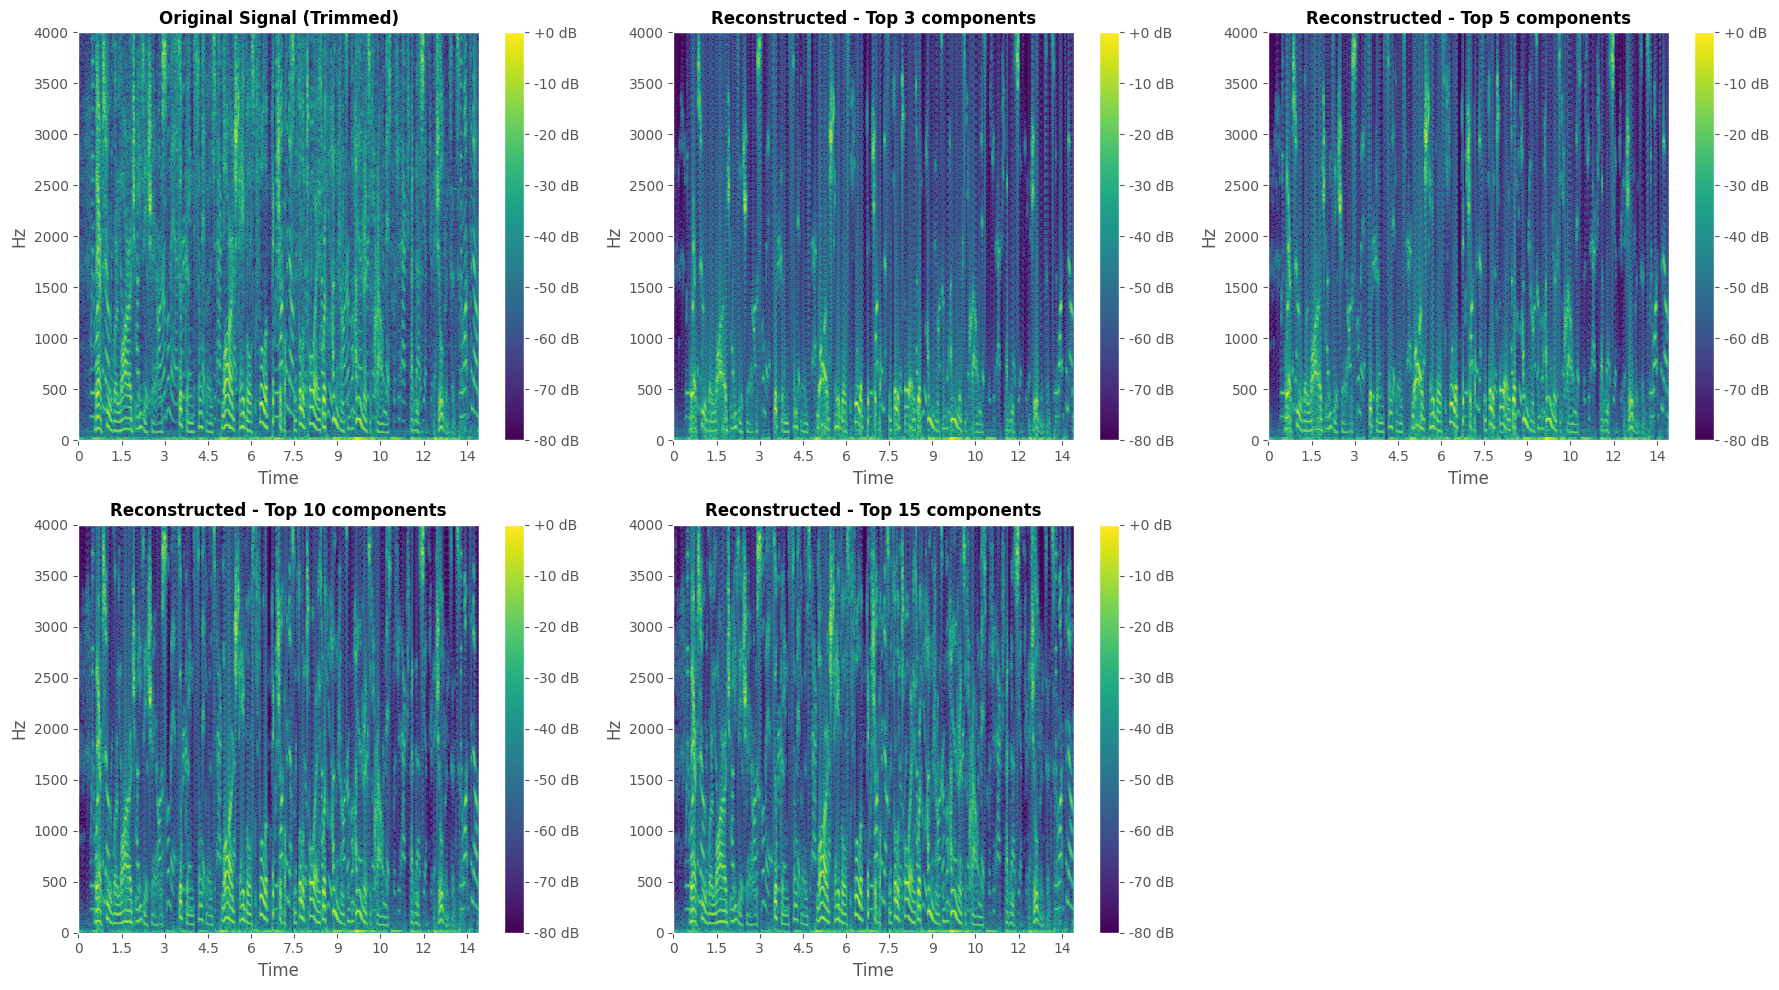

In [85]:
num_plots = len(reconstructions) + 1
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Use trimmed signal
signal_trimmed = signal_noisy[:num_frames * frame_size]

# Original
D_original = librosa.amplitude_to_db(np.abs(librosa.stft(signal_trimmed)), ref=np.max)
img = librosa.display.specshow(D_original, sr=sr, x_axis='time', y_axis='hz', ax=axes[0], cmap='viridis')
axes[0].set_title('Original Signal (Trimmed)', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, sr//2 if sr < 8000 else 4000])
plt.colorbar(img, ax=axes[0], format='%+2.0f dB')

# Reconstructions
for idx, (name, signal_rec) in enumerate(reconstructed_signals.items(), 1):
    D_rec = librosa.amplitude_to_db(np.abs(librosa.stft(signal_rec)), ref=np.max)
    img = librosa.display.specshow(D_rec, sr=sr, x_axis='time', y_axis='hz', ax=axes[idx], cmap='viridis')
    axes[idx].set_title(f'Reconstructed - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim([0, sr//2 if sr < 8000 else 4000])
    plt.colorbar(img, ax=axes[idx], format='%+2.0f dB')

# Hide last subplot if not needed
if len(reconstructions) < 5:
    axes[5].axis('off')

plt.tight_layout()
plt.show()

## 8. Audio Playback Comparison

Listen to the original and reconstructed signals.

In [86]:
# Use trimmed signal for comparison
signal_trimmed = signal_noisy[:num_frames * frame_size]

print("🔊 Original Signal (Trimmed):")
display(Audio(signal_trimmed, rate=sr))

print("\n" + "="*60 + "\n")

for name, signal_rec in reconstructed_signals.items():
    print(f"🔊 {name}:")
    display(Audio(signal_rec, rate=sr))
    print("\n" + "-"*60 + "\n")

🔊 Original Signal (Trimmed):




🔊 Top 3 components:



------------------------------------------------------------

🔊 Top 5 components:



------------------------------------------------------------

🔊 Top 10 components:



------------------------------------------------------------

🔊 Top 15 components:



------------------------------------------------------------



## 9. Individual Component Analysis

Visualize individual SSA components.

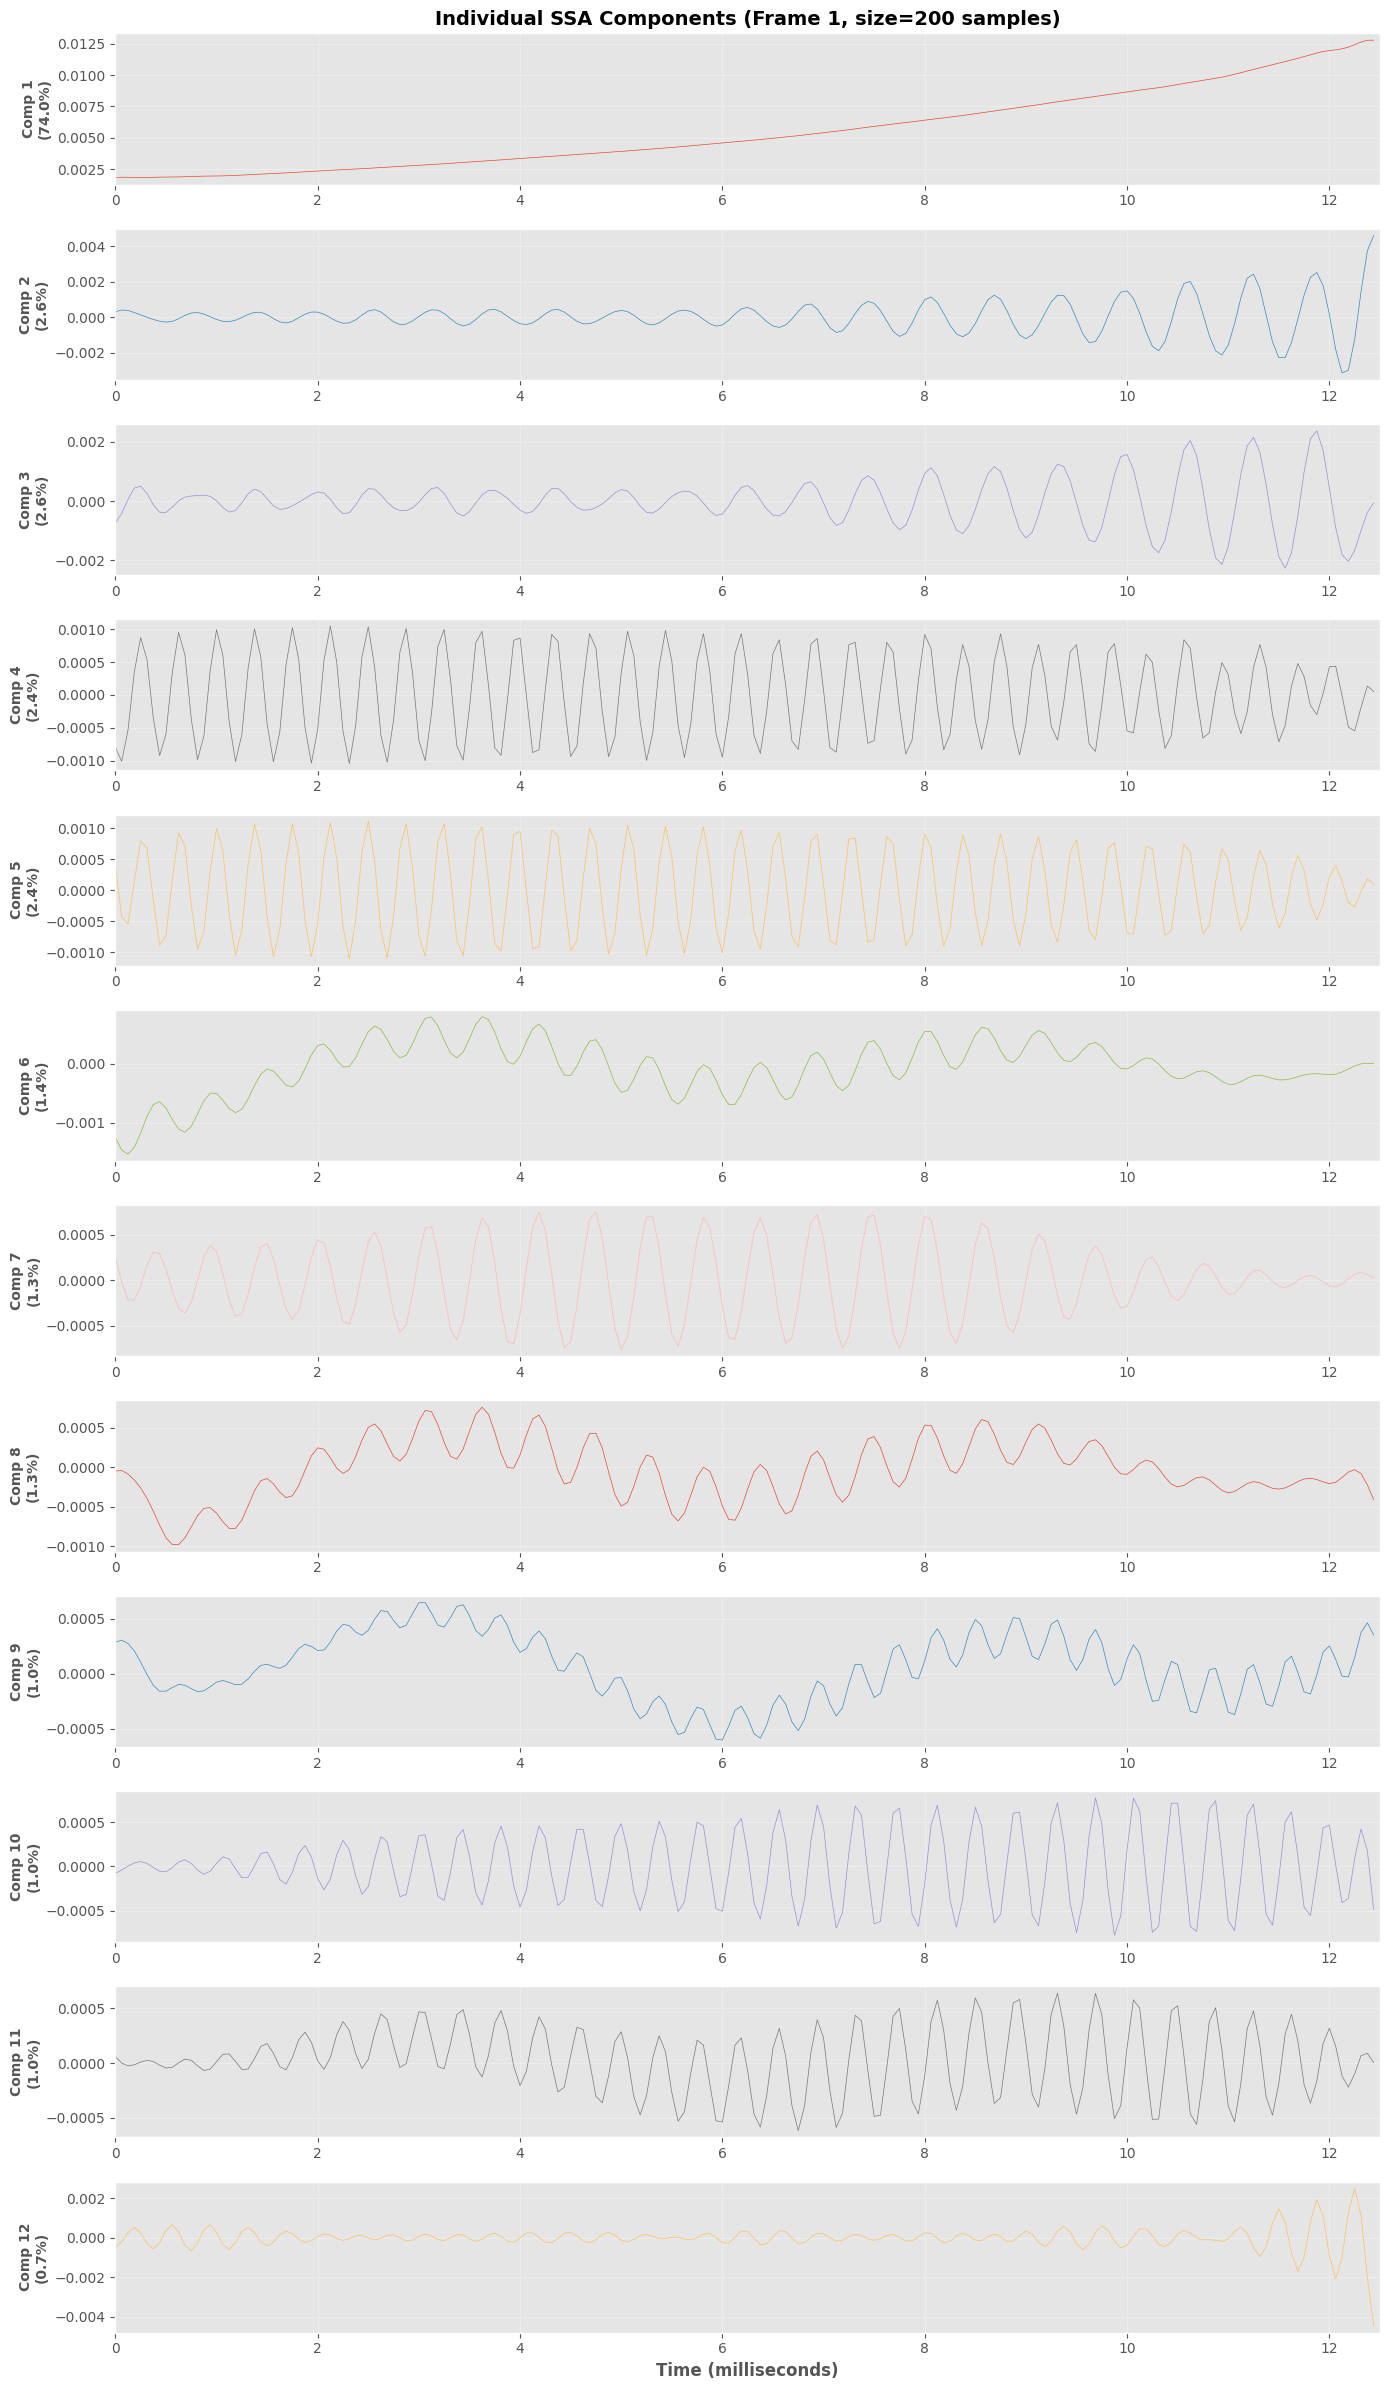

In [87]:
# Analyze components of the first frame
frame_idx = 0
U_frame, s_frame, Vt_frame, X_frame = perform_ssa(frames[frame_idx], window_length)

# Calculate contribution of each component for this frame
explained_variance_frame = (s_frame ** 2) / np.sum(s_frame ** 2) * 100

# Plot first 12 components from the first frame
n_components_to_plot = min(12, len(s_frame))
fig, axes = plt.subplots(n_components_to_plot, 1, figsize=(14, 2 * n_components_to_plot))

if n_components_to_plot == 1:
    axes = [axes]

for i in range(n_components_to_plot):
    component = reconstruct_component(U_frame, s_frame, Vt_frame, [i], frame_size)
    time_frame = np.arange(len(component)) / sr * 1000  # milliseconds
    
    axes[i].plot(time_frame, component, linewidth=0.5, color=f'C{i}')
    axes[i].set_ylabel(f'Comp {i+1}\n({explained_variance_frame[i]:.1f}%)', 
                       fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, frame_size / sr * 1000])
    
    if i == 0:
        axes[i].set_title(f'Individual SSA Components (Frame 1, size={frame_size} samples)', 
                         fontsize=14, fontweight='bold')

axes[-1].set_xlabel('Time (milliseconds)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Save Reconstructed Audio

Export the best reconstruction to a file.

In [88]:
# Choose the reconstruction you want to save
best_reconstruction = reconstructed_signals['Top 20 components']

# Normalize
best_reconstruction = best_reconstruction / np.max(np.abs(best_reconstruction)) * 0.9

# Save
output_path = 'ssa_reconstructed_speech.wav'
sf.write(output_path, best_reconstruction, sr)
print(f"✓ Saved reconstructed audio to: {output_path}")

KeyError: 'Top 20 components'

## Summary

### Key Observations:

1. **Low-rank components** capture the main signal structure
2. **Top 5-10 components** often capture most of the signal energy
3. **Higher components** contain noise and fine details
4. **Optimal reconstruction** balances signal quality and noise reduction

### Applications:

- **Denoising**: Remove high-index components containing noise
- **Trend extraction**: Use first few components for long-term trends
- **Periodic detection**: Identify periodic components
- **Signal compression**: Store only significant components

### Tips:

- **Window length**: Typically N/4 to N/2 works well
- **Component selection**: Use scree plot and variance explained
- **Validation**: Always listen to reconstructed audio
- **Experimentation**: Try different component combinations